In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import radians, cos, sin, asin, sqrt

df = pd.read_csv("df_assignment.csv.gz", )


focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]


* Step 1: Divide San Francisco into a grid of approximately 
 cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.

In [7]:
# theft data
theft_data = df[df["category"] == "larceny theft"]

lon = pd.to_numeric(theft_data["longitude"], errors="coerce")
lat = pd.to_numeric(theft_data["latitude"], errors="coerce")

mask = (
    (lon > -123.0) & (lon < -122.) &
    (lat > 37.0)   & (lat < 38.18)
)

lon = lon[mask].to_numpy()
lat = lat[mask].to_numpy()


def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

# after some testing we found that 0.2 km is a good bin size for our grid
bin_size_km = 0.2  

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

height_km = haversine(lon_min, lat_min, lon_min, lat_max)

width_km_bottom = haversine(lon_min, lat_min, lon_max, lat_min)
width_km_top    = haversine(lon_min, lat_max, lon_max, lat_max)
width_km = 0.5 * (width_km_bottom + width_km_top)

n_lat_bins = int(np.ceil(height_km / bin_size_km))
n_lon_bins = int(np.ceil(width_km  / bin_size_km))

print( "amount_lon_bins:", n_lon_bins, "amount_lat_bins:", n_lat_bins)

total_cells = n_lon_bins * n_lat_bins
print("total cells:", total_cells)

amount_lon_bins: 66 amount_lat_bins: 68
total cells: 4488


* Step 2: Count the number of incidents of your chosen crime in each grid cell (use all years of data).

* Step 3: Tally the distribution. Count how many cells have exactly 
 incidents — call this 
 — for 
 up to the maximum.


In [14]:
counts, lon_edges, lat_edges = np.histogram2d(
    lon, lat,
    bins=[n_lon_bins, n_lat_bins],
    range=[[lon_min, lon_max], [lat_min, lat_max]]
)

cell_counts = counts.flatten().astype(int)

# counting how many cells have k counts
nk = np.bincount(cell_counts)
k_vals = np.arange(len(nk))

print("Amount of empty cells:", nk[0])

Amount of empty cells: 1894


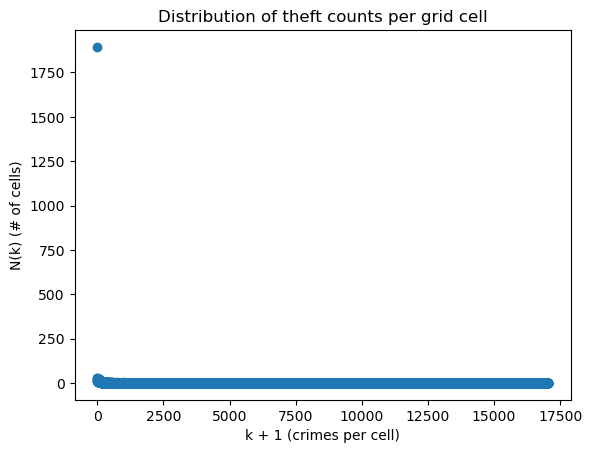

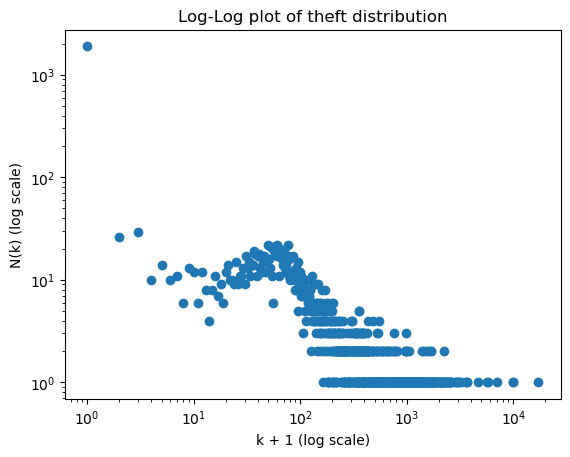

In [17]:
plt.figure()
plt.plot(k_vals + 1, nk, marker="o", linestyle="none")
plt.xlabel("k + 1 (crimes per cell)")
plt.ylabel("N(k) (# of cells)")
plt.title("Distribution of theft counts per grid cell")
plt.show()

plt.figure()
plt.loglog(k_vals + 1, nk, marker="o", linestyle="none")
plt.xlabel("k + 1 (log scale)")
plt.ylabel("N(k) (log scale)")
plt.title("Log-Log plot of theft distribution")
plt.show()

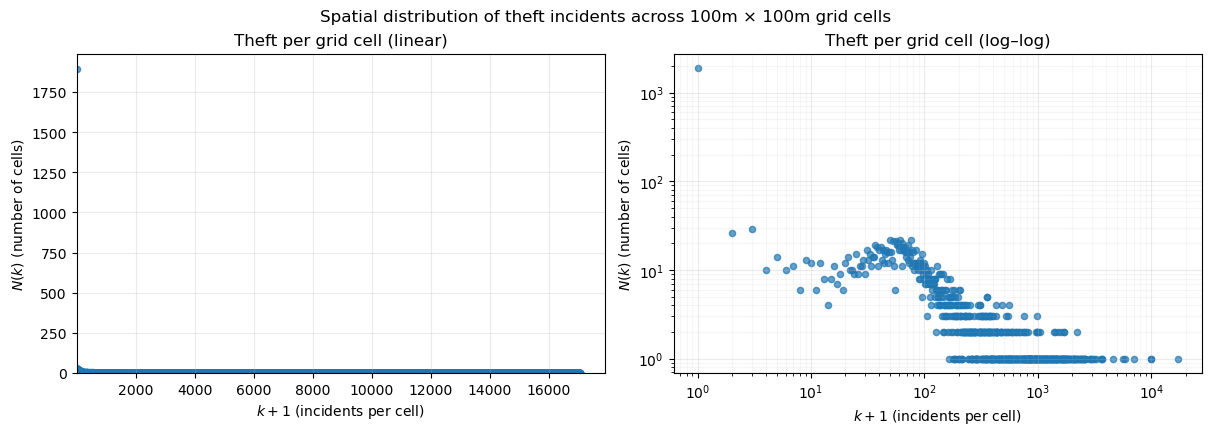

In [19]:
x = k_vals + 1
y = nk

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# --- Linear plot ---
ax = axes[0]
ax.scatter(x, y, s=20, alpha=0.7)
ax.set_title("Theft per grid cell (linear)")
ax.set_xlabel(r"$k + 1$ (incidents per cell)")
ax.set_ylabel(r"$N(k)$ (number of cells)")
ax.grid(True, alpha=0.25)

ax.set_ylim(bottom=0)
ax.set_xlim(left=1)

# Optional: improve readability by trimming extreme tail
# x_max = np.percentile(x, 99)
# ax.set_xlim(1, x_max)


# --- Log-log plot ---
ax = axes[1]

mask = y > 0
ax.scatter(x[mask], y[mask], s=20, alpha=0.7)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Theft per grid cell (log–log)")
ax.set_xlabel(r"$k + 1$ (incidents per cell)")
ax.set_ylabel(r"$N(k)$ (number of cells)")

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.1)

fig.suptitle(
    "Spatial distribution of theft incidents across 100m × 100m grid cells",
    y=1.05
)

plt.show()